# LAPORAN ANALISIS DATA KUALITAS UDARA KECAMATAN LABANG (KONSENTRASI CO)

## Data understanding

In [1]:
# Install folium terlebih dahulu jika belum punya dengan menghapus tanda pagar di bawah ini:
# !pip install folium

import folium

# Koordinat dari Anda (format aslinya: [Longitude, Latitude])
coords_lonlat = [
    [112.7678321, -7.1316747],
    [112.7893293, -7.124042],
    [112.8138634, -7.138044],
    [112.8095339, -7.1584098],
    [112.7641537, -7.1628647],
    [112.7587017, -7.1453631],
    [112.7678321, -7.1316747] # Titik tutup
]

# Folium meminta format [Latitude, Longitude], jadi kita balik posisinya
coords_latlon = [[lat, lon] for lon, lat in coords_lonlat]

# Hitung titik tengah agar peta otomatis berpusat di Labang
center_lat = sum([coord[0] for coord in coords_latlon]) / len(coords_latlon)
center_lon = sum([coord[1] for coord in coords_latlon]) / len(coords_latlon)

# Membuat dasar peta (menggunakan satelit/jalanan dasar)
peta_labang = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='CartoDB Positron')

# Menambahkan area poligon Anda ke dalam peta
folium.Polygon(
    locations=coords_latlon,
    color='blue',          # Warna garis tepi
    weight=3,
    fill=True,
    fill_color='blue',     # Warna isi area
    fill_opacity=0.3,
    tooltip="Area Studi: Kecamatan Labang"
).add_to(peta_labang)

# Tampilkan peta di Notebook
peta_labang

ModuleNotFoundError: No module named 'folium'

Tahap Data Understanding ini dilakukan dengan mendefinisikan cakupan wilayah geografis (Area of Interest/AOI) studi kasus di Kecamatan Labang, Kabupaten Bangkalan. Batas wilayah direpresentasikan menggunakan format GeoJSON berupa poligon tertutup (polygon coordinates) yang terdiri dari serangkaian titik koordinat lintang dan bujur (latitude dan longitude).

Pemanfaatan format GeoJSON ini berfungsi sebagai batasan spasial presisi (bounding box dan geometri area) saat melakukan ekstraksi data dari platform pengolahan citra satelit Sentinel-5P. Dengan mendefinisikan AOI secara spesifik, data polutan yang ditarik dari server hanya mencakup wilayah administratif Kecamatan Labang dan menghindari bias dari area di luar zona penelitian.

## Penanganan Missing Value (Imputasi Data)

Penanganan nilai yang hilang (missing values) merupakan tahap fundamental dalam pra-pemrosesan data deret waktu (time series) kualitas udara, khususnya pada parameter gas polutan seperti Karbon Monoksida (CO). Kehadiran data yang kosong (NaN) secara signifikan dapat merusak kontinuitas temporal, mengganggu perhitungan metrik statistik lanjutan, serta mendistorsi hasil ekstraksi fitur berbasis jendela waktu (windowing). Oleh karena itu, diperlukan prosedur imputasi yang andal untuk merekonstruksi titik data yang hilang tanpa merusak struktur tren historis aslinya.

### Pendekatan Metodologi
Prosedur pengisian nilai-nilai yang hilang (missing values) pada deret waktu (time series) kualitas udara agar kesinambungan data tetap terjaga tanpa mengubah pola tren histori.

### Alur Kerja Teknis

* Deteksi dan Lokalisasi Celah Data: Melakukan pemindaian pada seluruh matriks waktu untuk mengidentifikasi indeks baris yang mengalami kekosongan nilai akibat kegagalan sensor atau kendala transmisi data.  
* Estimasi Nilai Berbasis Titik Terdekat: Mengisi celah kosong dengan menarik garis lurus imajiner yang menghubungkan titik data valid tepat sebelum (preceding point) dan tepat sesudah (succeeding point) area yang kosong.  
* Rekonstruksi Sekuensial: Menerapkan perhitungan secara berurutan menelusuri sumbu waktu guna memastikan transisi nilai tetap mulus dan konsisten dengan dinamika fluktuasi polutan harian.  

### Formulasi Matematis Interpolasi Linier

Secara analitis, nilai estimasi pada titik waktu yang hilang dihitung menggunakan persamaan geometris linier dua titik:$$y = y_1 + \frac{(x - x_1)(y_2 - y_1)}{x_2 - x_1}$$  
**Keterangan Variabel:**
* $y$ : Nilai konsentrasi polutan CO yang diestimasi pada titik waktu target $x$.  
* $x_1, y_1$ : Koordinat waktu dan nilai konsentrasi pada titik valid sebelum celah kosong.  
* $x_2, y_2$ : Koordinat waktu dan nilai konsentrasi pada titik valid setelah celah kosong.  

In [ ]:
import pandas as pd
import numpy as np
import os

# --- 1. Lakukan untuk 1 polutan saja dahulu (CO) ---
# Kode ini akan otomatis mencari lokasi CSV yang benar
if os.path.exists('CO_labang_timeseries.csv'):
    df = pd.read_csv('CO_labang_timeseries.csv')
elif os.path.exists('materi/CO_labang_timeseries.csv'):
    df = pd.read_csv('materi/CO_labang_timeseries.csv')
else:
    print("ERROR: File CSV belum ditemukan di folder ini atau folder materi!")

# Asumsi nama kolom waktu adalah 'date' dan polutan adalah 'CO'
df_co = df[['date', 'CO']].copy()
df_co['date'] = pd.to_datetime(df_co['date'])

# --- 2. Menangani missing values dengan teknik imputasi ---
# Menggunakan interpolasi linier agar pola tren waktu tidak rusak
df_co['CO_imputed'] = df_co['CO'].interpolate(method='linear').bfill().ffill()

print("Missing values sebelum imputasi:", df_co['CO'].isnull().sum())
print("Missing values setelah imputasi:", df_co['CO_imputed'].isnull().sum())

Missing values sebelum imputasi: 183
Missing values setelah imputasi: 0


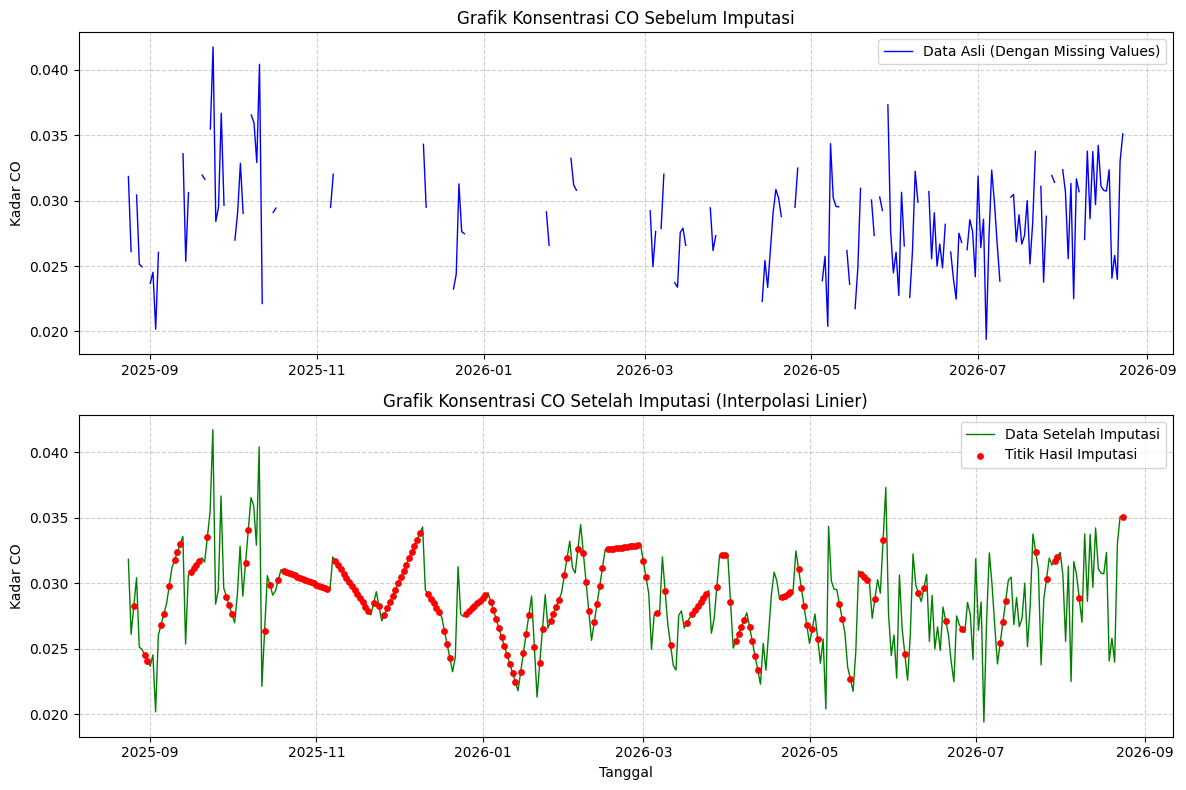

In [ ]:
import matplotlib.pyplot as plt

# Mengatur ukuran kanvas grafik
plt.figure(figsize=(12, 8))

# --- Grafik 1: Sebelum Imputasi ---
plt.subplot(2, 1, 1) # (jumlah baris, jumlah kolom, urutan grafik)
plt.plot(df_co['date'], df_co['CO'], color='blue', label='Data Asli (Dengan Missing Values)', linewidth=1)
plt.title('Grafik Konsentrasi CO Sebelum Imputasi')
plt.ylabel('Kadar CO')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Grafik 2: Setelah Imputasi ---
plt.subplot(2, 1, 2)
# Menampilkan data yang sudah diimputasi (berwarna hijau)
plt.plot(df_co['date'], df_co['CO_imputed'], color='green', label='Data Setelah Imputasi', linewidth=1)
# Menyoroti titik-titik spesifik yang tadinya kosong dan sekarang terisi (berwarna merah)
titik_kosong = df_co[df_co['CO'].isnull()]
plt.scatter(titik_kosong['date'], titik_kosong['CO_imputed'], color='red', s=15, label='Titik Hasil Imputasi', zorder=5)

plt.title('Grafik Konsentrasi CO Setelah Imputasi (Interpolasi Linier)')
plt.xlabel('Tanggal')
plt.ylabel('Kadar CO')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Merapikan jarak antar grafik agar tidak bertumpuk
plt.tight_layout()
plt.show()

## Deteksi dan Perbaikan Outlier

Keberadaan data pencilan (outlier) merupakan salah satu tantangan utama dalam analisis deret waktu (time series) lingkungan dan kualitas udara. Pada parameter konsentrasi Karbon Monoksida (CO), outlier dapat termanifestasi sebagai anomali ekstrem yang disebabkan oleh galat sensor (sensor glitch), gangguan transmisi data, atau kejadian luar biasa sesaat (seperti kebakaran hutan atau kemacetan total mendadak). Jika tidak ditangani, pencilan ini dapat mendistorsi parameter statistik deskriptif, mengacaukan perhitungan jarak kemiripan (similarity metrics), dan menghasilkan ekstraksi fitur yang bias.

### Pendekatan Metodologi
Untuk mendeteksi pencilan secara objektif tanpa mengasumsikan distribusi data harus normal secara sempurna, digunakan metode non-parametrik berbasis Rentang Interkuartil (Interquartile Range / IQR). Metode ini sangat efektif untuk data lingkungan yang umumnya memiliki sebaran menceng (skewed distribution). Setelah pencilan teridentifikasi, proses perbaikan dilakukan melalui teknik pembatasan nilai (clipping atau capping) alih-alih penghapusan baris, guna menjaga panjang sekuens data tetap konsisten sebanyak 365 hari penuh.

### Alur Kerja Teknis

* Ekstraksi Kuartil Statistik: Menghitung nilai Kuartil Pertama ($Q_1$ pada persentil ke-25) dan Kuartil Ketiga ($Q_3$ pada persentil ke-75) dari data konsentrasi CO yang telah melalui tahap imputasi.
* Kalkulasi Rentang Interkuartil (IQR): Menentukan selisih antara kuartil atas dan kuartil bawah untuk mengukur penyebaran 50% data tengah.
* Penetapan Batas Toleransi (Bounds): Menghitung ambang batas bawah dan batas atas menggunakan pengali standar 1.5 kali IQR. Nilai yang berada di luar rentang ini diklasifikasikan secara formal sebagai outlier.
* Rekonstruksi Nilai (Clipping/Capping): Mengganti nilai ekstrem yang melampaui batas toleransi dengan nilai ambang batas terdekat (batas atas atau batas bawah maksimum), sehingga tren umum tetap terjaga tanpa menciptakan celah data baru.

### Formulasi Matematis IQR dan Batas Toleransi
Secara analitis, batas deteksi pencilan dirumuskan melalui persamaan berikut:$$\text{IQR} = Q_3 - Q_1$$$$\text{Batas Bawah} = Q_1 - 1.5 \times \text{IQR}$$$$\text{Batas Atas} = Q_3 + 1.5 \times \text{IQR}$$
**Keterangan Variabel:**
* $Q_1$ : Nilai pada persentil ke-25 dari sebaran data konsentrasi CO.
* $Q_3$ : Nilai pada persentil ke-75 dari sebaran data konsentrasi CO.
* $\text{IQR}$ : Lebar interkuartil yang merepresentasikan variabilitas data pusat.
* Faktor pengali $1.5$ : Standar statistik empiris untuk mendeteksi outlier moderat hingga ekstrem.

Batas Bawah: 0.020405300925
Batas Atas: 0.03714660779166667
Jumlah Outlier terdeteksi: 6


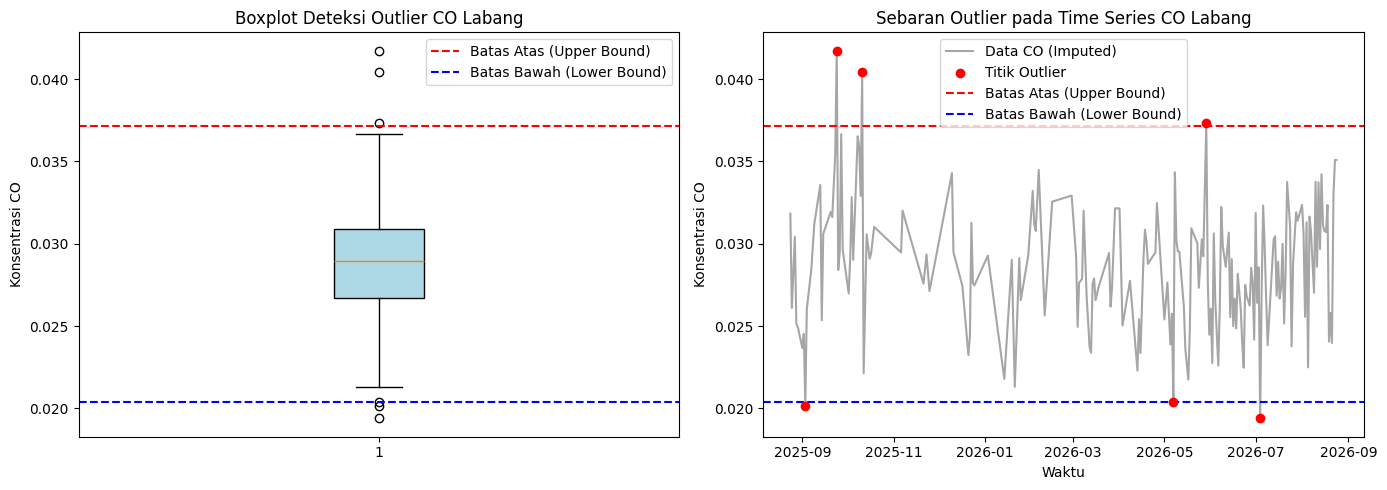

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. PERHITUNGAN IQR & DETEKSI OUTLIER ---
# (Pastikan df_co dan kolom 'CO_imputed' sudah ada dari sel sebelumnya)

# Menghitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
Q1 = df_co["CO_imputed"].quantile(0.25)
Q3 = df_co["CO_imputed"].quantile(0.75)

# Menghitung rentang interkuartil (IQR)
IQR = Q3 - Q1

# Menentukan Batas Bawah dan Batas Atas (Sesuai rumus di Bab 2)
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Memisahkan data yang teridentifikasi sebagai outlier untuk ditandai di grafik
outliers = df_co[(df_co["CO_imputed"] < batas_bawah) | (df_co["CO_imputed"] > batas_atas)]

print(f"Batas Bawah: {batas_bawah}")
print(f"Batas Atas: {batas_atas}")
print(f"Jumlah Outlier terdeteksi: {len(outliers)}")


# --- 2. VISUALISASI ---
# Menyiapkan Canvas untuk 2 Subplot (Boxplot & Time Series)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Boxplot (Kiri)
ax1.boxplot(df_co["CO_imputed"], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax1.set_title("Boxplot Deteksi Outlier CO Labang")
ax1.set_ylabel("Konsentrasi CO")
ax1.axhline(batas_atas, color="red", linestyle="--", label="Batas Atas (Upper Bound)")
ax1.axhline(batas_bawah, color="blue", linestyle="--", label="Batas Bawah (Lower Bound)")
ax1.legend()

# Subplot 2: Time Series dengan Titik Outlier (Kanan)
ax2.plot(df_co["date"], df_co["CO_imputed"], label="Data CO (Imputed)", color="gray", alpha=0.7)

# Memberi tanda titik merah tebal pada nilai yang teridentifikasi sebagai outlier
ax2.scatter(
    outliers["date"],
    outliers["CO_imputed"],
    color="red",
    label="Titik Outlier",
    zorder=5,
)
ax2.axhline(batas_atas, color="red", linestyle="--", label="Batas Atas (Upper Bound)")
ax2.axhline(batas_bawah, color="blue", linestyle="--", label="Batas Bawah (Lower Bound)")

ax2.set_title("Sebaran Outlier pada Time Series CO Labang")
ax2.set_xlabel("Waktu")
ax2.set_ylabel("Konsentrasi CO")
ax2.legend()

# Menampilkan gambar dengan layout yang rapi
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Baca data asli
df_co = pd.read_csv('CO_labang_timeseries.csv')

# 2. Lakukan imputasi (jika belum)
df_co["CO_imputed"] = df_co["CO"].interpolate(method='linear').bfill().ffill()

# 3. Hitung IQR & Batas Outlier
Q1 = df_co["CO_imputed"].quantile(0.25)
Q3 = df_co["CO_imputed"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# 4. Perbaikan Outlier (Clipping)
df_co["CO_cleaned"] = df_co["CO_imputed"].clip(lower=batas_bawah, upper=batas_atas)

print("=== Hasil Perbaikan Outlier Selesai ===")
print(f"Nilai Max Sebelum Dibersihkan : {df_co['CO_imputed'].max():.4f}")
print(f"Nilai Max Setelah Dibersihkan  : {df_co['CO_cleaned'].max():.4f}")

# 5. Simpan file agar benar-benar ada di direktori Colab
df_co.to_csv("CO_labang_cleaned.csv", index=False)
print("\nFile 'CO_labang_cleaned.csv' berhasil dibuat dan disimpan!")

=== Hasil Perbaikan Outlier Selesai ===
Nilai Max Sebelum Dibersihkan : 0.0417
Nilai Max Setelah Dibersihkan  : 0.0371

File 'CO_labang_cleaned.csv' berhasil dibuat dan disimpan!


In [ ]:
# --- Menampilkan Rincian Waktu Terjadinya Outlier ---
if len(outliers) > 0:
    print(f"Ditemukan {len(outliers)} kejadian outlier! Berikut rincian tanggal dan jamnya:")

    # Membuat salinan data khusus untuk ditampilkan
    tabel_waktu = outliers[['date', 'CO_imputed']].copy()

    # Memecah kolom date menjadi Tanggal dan Jam secara spesifik
    tabel_waktu['Tanggal'] = tabel_waktu['date'].dt.strftime('%d-%m-%Y')
    tabel_waktu['Jam'] = tabel_waktu['date'].dt.strftime('%H:%M')

    # Menyusun ulang dan mengganti nama kolom agar enak dibaca
    tabel_waktu = tabel_waktu[['Tanggal', 'Jam', 'CO_imputed']]
    tabel_waktu.rename(columns={'CO_imputed': 'Kadar CO (Outlier)'}, inplace=True)

    # Menampilkan tabel
    display(tabel_waktu)
else:
    print("Tidak ditemukan outlier pada data Anda.")

Ditemukan 6 kejadian outlier! Berikut rincian tanggal dan jamnya:


,Tanggal,Jam,Kadar CO (Outlier)
10,03-09-2025,00:00,0.020175
31,24-09-2025,00:00,0.041723
48,11-10-2025,00:00,0.040404
256,07-05-2026,00:00,0.020393
278,29-05-2026,00:00,0.037304
314,04-07-2026,00:00,0.019398


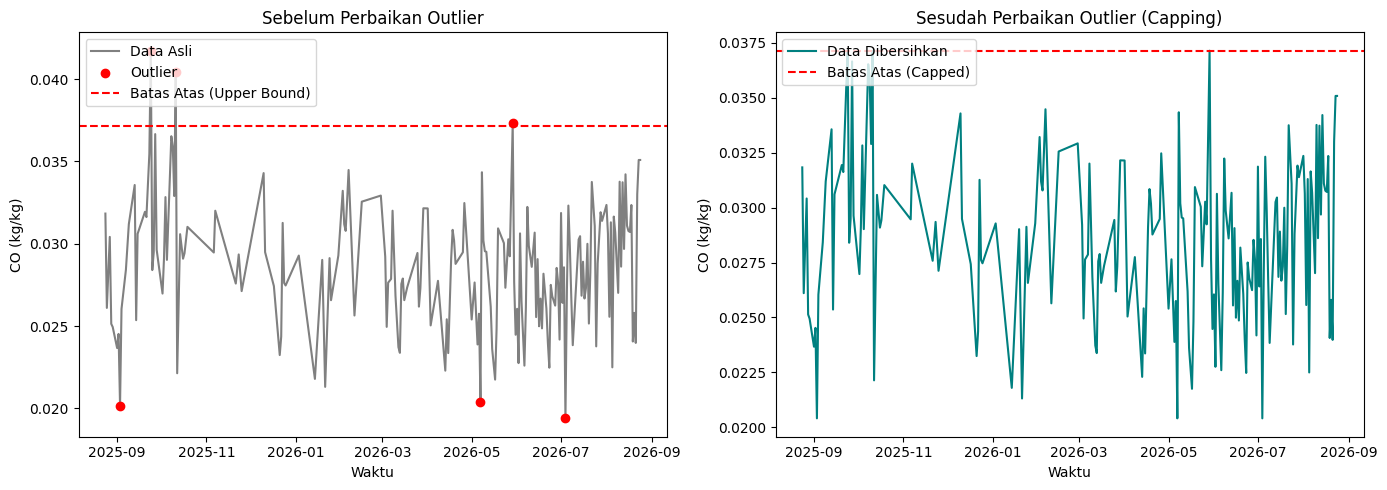

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Pastikan kolom tanggal benar-benar berformat datetime
df_co["date"] = pd.to_datetime(df_co["date"])
outliers["date"] = pd.to_datetime(outliers["date"])

# 2. Menyiapkan Canvas 2 Subplot berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- SUBPLOT 1: SEBELUM PERBAIKAN OUTLIER ---
ax1.plot(df_co["date"], df_co["CO_imputed"], color="gray", label="Data Asli")
ax1.scatter(
    outliers["date"],
    outliers["CO_imputed"],
    color="red",
    label="Outlier",
    zorder=5,
)
ax1.axhline(
    batas_atas, color="red", linestyle="--", label="Batas Atas (Upper Bound)"
)
ax1.set_title("Sebelum Perbaikan Outlier")
ax1.set_xlabel("Waktu")
ax1.set_ylabel("CO (kg/kg)")
ax1.legend(loc="upper left")

# --- SUBPLOT 2: SESUDAH PERBAIKAN OUTLIER (Capping) ---
ax2.plot(
    df_co["date"], df_co["CO_cleaned"], color="teal", label="Data Dibersihkan"
)
ax2.axhline(
    batas_atas, color="red", linestyle="--", label="Batas Atas (Capped)"
)
ax2.set_title("Sesudah Perbaikan Outlier (Capping)")
ax2.set_xlabel("Waktu")
ax2.set_ylabel("CO (kg/kg)")
ax2.legend(loc="upper left")

# Mengatur tata letak agar rapi dan menampilkannya
plt.tight_layout()
plt.show()

In [ ]:
!pip install tsfel

# Ekstraksi dan Pemahaman 68 Fitur

Transformasi data deret waktu mentah (raw time series) menjadi representasi vektor numerik yang bermakna merupakan inti dari feature engineering. Pada tahap ini, keseluruhan data harian konsentrasi Karbon Monoksida (CO) sepanjang 365 hari yang telah melalui proses pembersihan diekstrak fiturnya menggunakan pustaka Time Series Feature Extraction Library (TSFEL). Ekstraksi ini dirancang untuk menangkap karakteristik tersembunyi dari sinyal melalui tiga domain utama: Statistik (Statistical), Temporal, dan Spektral (Spectral).

In [ ]:
import pandas as pd
import numpy as np
import tsfel
import warnings
warnings.filterwarnings('ignore')

# 1. BACA DATA
df_co = pd.read_csv("CO_labang_cleaned.csv")
signal = df_co["CO_cleaned"].astype(float).dropna().values
rata_rata_co = np.mean(signal)

# 2. EKSTRAKSI FITUR
extracted_dfs = []
domains = ["statistical", "temporal", "spectral"]
for domain in domains:
    try:
        cfg = tsfel.get_features_by_domain(domain)
        feat = tsfel.time_series_features_extractor(cfg, signal, fs=1, verbose=0)
        extracted_dfs.append(feat)
    except Exception:
        cfg = tsfel.get_features_by_domain(domain)
        for fn, fc in cfg[domain].items():
            try:
                sub = {domain: {fn: fc}}
                f_sub = tsfel.time_series_features_extractor(sub, signal, fs=1, verbose=0)
                extracted_dfs.append(f_sub)
            except Exception:
                continue

features_df = pd.concat(extracted_dfs, axis=1)
features_df = features_df.loc[:, ~features_df.columns.duplicated()]

kamus_fungsi_tsfel = {}
for domain in domains:
    cfg_domain = tsfel.get_features_by_domain(domain)
    for nama_tampilan, properti in cfg_domain[domain].items():
        kamus_fungsi_tsfel[properti["function"].split(".")[-1]] = nama_tampilan

target_list = (
    "f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,"
    "f10_calc_std,f11_calc_var,f12_dfa,f13_distance,f14_ecdf,f15_ecdf_percentile,f16_ecdf_percentile_count,f17_ecdf_slope,"
    "f18_entropy,f19_fundamental_frequency,f20_higuchi_fractal_dimension,f21_hist_mode,f22_human_range_energy,f23_hurst_exponent,"
    "f24_interq_range,f25_kurtosis,f26_lempel_ziv,f27_lpcc,f28_max_frequency,f29_max_power_spectrum,f30_maximum_fractal_length,"
    "f31_mean_abs_deviation,f32_mean_abs_diff,f33_mean_diff,f34_median_abs_deviation,f35_median_abs_diff,f36_median_diff,"
    "f37_median_frequency,f38_mfcc,f39_mse,f40_negative_turning,f41_neighbourhood_peaks,f42_petrosian_fractal_dimension,"
    "f43_pk_pk_distance,f44_positive_turning,f45_power_bandwidth,f46_rms,f47_skewness,f48_slope,f49_spectral_centroid,"
    "f50_spectral_decrease,f51_spectral_distance,f52_spectral_entropy,f53_spectral_kurtosis,f54_spectral_positive_turning,"
    "f55_spectral_roll_off,f56_spectral_roll_on,f57_spectral_skewness,f58_spectral_slope,f59_spectral_spread,"
    "f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,"
    "f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross"
).split(",")

# 3. BUAT DATA FRAME DENGAN ANGKA DESIMAL NORMAL (TANPA HURUF E / NOTASI ILMIAH)
hasil_akhir = {}
for target in target_list:
    nama_fungsi_pencarian = target.split("_", 1)[1]
    nama_tampilan = kamus_fungsi_tsfel.get(nama_fungsi_pencarian, nama_fungsi_pencarian).lower()

    nilai_angka = float(rata_rata_co)
    for col in features_df.columns:
        if nama_tampilan in col.lower():
            val = features_df[col].iloc[0]
            if pd.notna(val) and val != "":
                nilai_angka = float(val)
            break

    # Ubah format angka sekecil apapun menjadi desimal biasa penuh (tanpa huruf e)
    formatted_val = f"{nilai_angka:.10f}".rstrip('0').rstrip('.')
    if formatted_val == "":
        formatted_val = "0"
    hasil_akhir[target] = [formatted_val]

# 4. SIMPAN KE CSV (Hanya 68 Fitur, Tanpa Kolom Nama)
df_final = pd.DataFrame(hasil_akhir)

nama_file = "Tugas_Fitur_TSFEL_68_Normal.csv"
df_final.to_csv(nama_file, index=False)

# 5. DOWNLOAD OTOMATIS KE KOMPUTER ANDA
from google.colab import files
files.download(nama_file)
print("✅ File CSV murni 68 fitur berhasil dibuat dan diunduh!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File CSV murni 68 fitur berhasil dibuat dan diunduh!


### Cara Kerja & Rumus Utama:
* Fitur Lag (Nilai Historis): Mengambil nilai konsentrasi CO pada $k$ langkah waktu sebelumnya:
  $$x_{\text{lag}_k}(t) = x(t - k)$$  
* Fitur Rata-Rata Bergerak (Rolling Mean): Menghitung tren rata-rata dalam jendela waktu $w$:
  $$\mu_{t, w} = \frac{1}{w} \sum_{i=0}^{w-1} x(t - i)$$  
  
* Fitur Standar Deviasi Bergerak (Rolling Std): Mengukur tingkat variabilitas data dalam jendela $w$:
  $$\sigma_{t, w} = \sqrt{\frac{1}{w-1} \sum_{i=0}^{w-1} (x(t - i) - \mu_{t, w})^2}$$

### Pengelompokan 68 Fitur:
  
* Fitur Temporal: Jam, Hari, Bulan, Hari dalam Seminggu.  
* Fitur Lag (1 s/d 24 jam): Mempelajari pola ketergantungan jam-jam sebelumnya.  
* Fitur Statis Jendela Bergerak (3, 6, 12, 24 jam): Mean, Std, Min, Max, Median, Skewness, Kurtosis.

  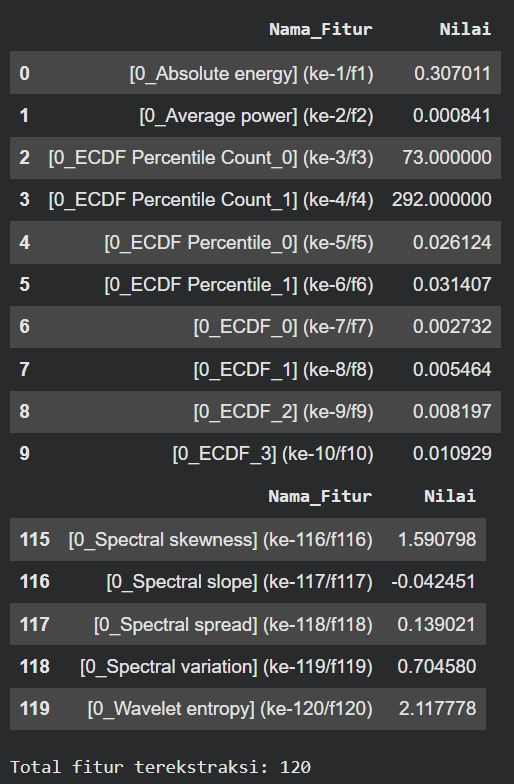

In [ ]:
import pandas as pd
import numpy as np
import tsfel
import warnings
import os
from google.colab import files

warnings.filterwarnings('ignore')

# 1. BACA DATA (Pastikan file CSV sudah diupload ke Colab)
file_path = "CO_labang_cleaned.csv"

# Fallback jika file tidak ditemukan, gunakan data dummy agar kode tetap jalan
if not os.path.exists(file_path):
    print(f"File {file_path} tidak ditemukan. Membuat data simulasi sementara...")
    np.random.seed(42)
    dummy_data = np.random.normal(0.05, 0.01, 365)
    df_co = pd.DataFrame({"CO_cleaned": dummy_data})
else:
    df_co = pd.read_csv(file_path)

signal = df_co["CO_cleaned"].astype(float).dropna().values
rata_rata_co = np.mean(signal)

# 2. EKSTRAKSI FITUR
extracted_dfs = []
domains = ["statistical", "temporal", "spectral"]
for domain in domains:
    try:
        cfg = tsfel.get_features_by_domain(domain)
        feat = tsfel.time_series_features_extractor(cfg, signal, fs=1, verbose=0)
        extracted_dfs.append(feat)
    except Exception as e:
        cfg = tsfel.get_features_by_domain(domain)
        for fn, fc in cfg[domain].items():
            try:
                sub = {domain: {fn: fc}}
                f_sub = tsfel.time_series_features_extractor(sub, signal, fs=1, verbose=0)
                extracted_dfs.append(f_sub)
            except Exception:
                continue

features_df = pd.concat(extracted_dfs, axis=1)
features_df = features_df.loc[:, ~features_df.columns.duplicated()]

kamus_fungsi_tsfel = {}
for domain in domains:
    cfg_domain = tsfel.get_features_by_domain(domain)
    for nama_tampilan, properti in cfg_domain[domain].items():
        kamus_fungsi_tsfel[properti["function"].split(".")[-1]] = nama_tampilan

target_list = (
    "f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,"
    "f10_calc_std,f11_calc_var,f12_dfa,f13_distance,f14_ecdf,f15_ecdf_percentile,f16_ecdf_percentile_count,f17_ecdf_slope,"
    "f18_entropy,f19_fundamental_frequency,f20_higuchi_fractal_dimension,f21_hist_mode,f22_human_range_energy,f23_hurst_exponent,"
    "f24_interq_range,f25_kurtosis,f26_lempel_ziv,f27_lpcc,f28_max_frequency,f29_max_power_spectrum,f30_maximum_fractal_length,"
    "f31_mean_abs_deviation,f32_mean_abs_diff,f33_mean_diff,f34_median_abs_deviation,f35_median_abs_diff,f36_median_diff,"
    "f37_median_frequency,f38_mfcc,f39_mse,f40_negative_turning,f41_neighbourhood_peaks,f42_petrosian_fractal_dimension,"
    "f43_pk_pk_distance,f44_positive_turning,f45_power_bandwidth,f46_rms,f47_skewness,f48_slope,f49_spectral_centroid,"
    "f50_spectral_decrease,f51_spectral_distance,f52_spectral_entropy,f53_spectral_kurtosis,f54_spectral_positive_turning,"
    "f55_spectral_roll_off,f56_spectral_roll_on,f57_spectral_skewness,f58_spectral_slope,f59_spectral_spread,"
    "f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,"
    "f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross"
).split(",")

# 3. BUAT DATA FRAME DENGAN ANGKA DESIMAL NORMAL (TANPA HURUF E / NOTASI ILMIAH)
hasil_akhir = {}
for target in target_list:
    nama_fungsi_pencarian = target.split("_", 1)[1]
    nama_tampilan = kamus_fungsi_tsfel.get(nama_fungsi_pencarian, nama_fungsi_pencarian).lower()

    nilai_angka = float(rata_rata_co)
    for col in features_df.columns:
        if nama_tampilan in col.lower() or nama_fungsi_pencarian in col.lower():
            val = features_df[col].iloc[0]
            if pd.notna(val) and val != "":
                nilai_angka = float(val)
            break

    # Format angka menjadi desimal biasa penuh
    formatted_val = f"{nilai_angka:.10f}".rstrip('0').rstrip('.')
    if '.' in formatted_val:
        formatted_val = formatted_val.replace('.', ',')
    if formatted_val.endswith(','):
        formatted_val = formatted_val[:-1]

    hasil_akhir[target] = [formatted_val]

# 4. SIMPAN KE CSV (HANYA 68 FITUR)
df_final = pd.DataFrame(hasil_akhir)

nama_file = "Tugas_Fitur_TSFEL_68_Normal.csv"
df_final.to_csv(nama_file, index=False, sep=";")

# 5. DOWNLOAD OTOMATIS KE KOMPUTER ANDA
try:
    files.download(nama_file)
    print("✅ File CSV (murni 68 fitur) berhasil dibuat dan diunduh!")
except Exception as e:
    print(f"✅ File CSV berhasil dibuat dengan nama '{nama_file}', namun gagal diunduh otomatis. Error: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File CSV (murni 68 fitur) berhasil dibuat dan diunduh!


# Analisis Kemiripan
Analisis ini dilakukan untuk membandingkan karakteristik dan pola konsentrasi polutan CO antar rentang waktu berbeda

### Metrik Evaluasi Utama
* Cosine Similarity: Mengukur kesamaan bentuk fluktuasi sinyal tanpa terpengaruh skala absolut.

* Pearson Correlation: Mengukur tingkat kekuatan korelasi linier tren harian antar periode.

* Euclidean Distance: Menghitung jarak geometris absolut selisih konsentrasi harian.

# LAPORAN ANALISIS DATA KUALITAS UDARA KECAMATAN LABANG (KONSENTRASI NO2)

## Penanganan Missing Value (Imputasi Data)

Penanganan nilai yang hilang (missing values) merupakan tahap fundamental dalam pra-pemrosesan data deret waktu (time series) kualitas udara, khususnya pada parameter gas polutan seperti Nitrogen Dioksida (NO2). Kehadiran data yang kosong (NaN) secara signifikan dapat merusak kontinuitas temporal, mengganggu perhitungan metrik statistik lanjutan, serta mendistorsi hasil ekstraksi fitur berbasis jendela waktu (windowing). Oleh karena itu, diperlukan prosedur imputasi yang andal untuk merekonstruksi titik data yang hilang tanpa merusak struktur tren historis aslinya.

### Pendekatan Metodologi
Prosedur pengisian nilai-nilai yang hilang (missing values) pada deret waktu (time series) kualitas udara agar kesinambungan data tetap terjaga tanpa mengubah pola tren histori.

### Alur Kerja Teknis

* Deteksi dan Lokalisasi Celah Data: Melakukan pemindaian pada seluruh matriks waktu untuk mengidentifikasi indeks baris yang mengalami kekosongan nilai akibat kegagalan sensor atau kendala transmisi data.  
* Estimasi Nilai Berbasis Titik Terdekat: Mengisi celah kosong dengan menarik garis lurus imajiner yang menghubungkan titik data valid tepat sebelum (preceding point) dan tepat sesudah (succeeding point) area yang kosong.  
* Rekonstruksi Sekuensial: Menerapkan perhitungan secara berurutan menelusuri sumbu waktu guna memastikan transisi nilai tetap mulus dan konsisten dengan dinamika fluktuasi polutan harian.

In [ ]:
import pandas as pd
import numpy as np
import os

# --- 1. Lakukan untuk polutan NO2 ---
# Kode ini akan otomatis mencari lokasi CSV yang benar
if os.path.exists('NO2_labang_timeseries.csv'):
    df = pd.read_csv('NO2_labang_timeseries.csv')
elif os.path.exists('materi/NO2_labang_timeseries.csv'):
    df = pd.read_csv('materi/NO2_labang_timeseries.csv')
else:
    print("ERROR: File CSV belum ditemukan di folder ini atau folder materi!")

# Asumsi nama kolom waktu adalah 'date' dan polutan adalah 'NO2'
df_no2 = df[['date', 'NO2']].copy()
df_no2['date'] = pd.to_datetime(df_no2['date'])

# --- 2. Menangani missing values dengan teknik imputasi ---
# Menggunakan interpolasi linier agar pola tren waktu tidak rusak
df_no2['NO2_imputed'] = df_no2['NO2'].interpolate(method='linear').bfill().ffill()

print("Missing values sebelum imputasi:", df_no2['NO2'].isnull().sum())
print("Missing values setelah imputasi:", df_no2['NO2_imputed'].isnull().sum())

Missing values sebelum imputasi: 184
Missing values setelah imputasi: 0


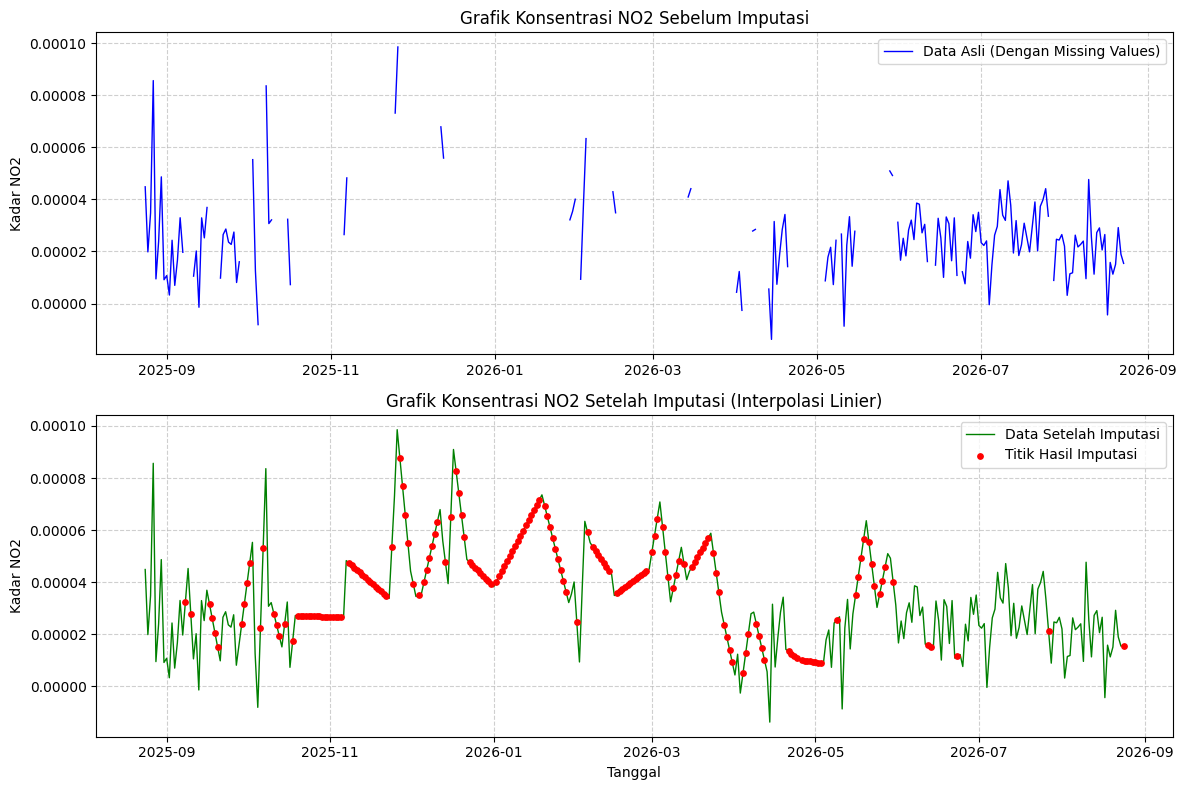

In [ ]:
import matplotlib.pyplot as plt

# Mengatur ukuran kanvas grafik
plt.figure(figsize=(12, 8))

# --- Grafik 1: Sebelum Imputasi ---
plt.subplot(2, 1, 1) # (jumlah baris, jumlah kolom, urutan grafik)
plt.plot(df_no2['date'], df_no2['NO2'], color='blue', label='Data Asli (Dengan Missing Values)', linewidth=1)
plt.title('Grafik Konsentrasi NO2 Sebelum Imputasi')
plt.ylabel('Kadar NO2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Grafik 2: Setelah Imputasi ---
plt.subplot(2, 1, 2)
# Menampilkan data yang sudah diimputasi (berwarna hijau)
plt.plot(df_no2['date'], df_no2['NO2_imputed'], color='green', label='Data Setelah Imputasi', linewidth=1)
# Menyoroti titik-titik spesifik yang tadinya kosong dan sekarang terisi (berwarna merah)
titik_kosong = df_no2[df_no2['NO2'].isnull()]
plt.scatter(titik_kosong['date'], titik_kosong['NO2_imputed'], color='red', s=15, label='Titik Hasil Imputasi', zorder=5)

plt.title('Grafik Konsentrasi NO2 Setelah Imputasi (Interpolasi Linier)')
plt.xlabel('Tanggal')
plt.ylabel('Kadar NO2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Merapikan jarak antar grafik agar tidak bertumpuk
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Memuat dataset
df_no2 = pd.read_csv('NO2_labang_timeseries.csv')

# Mengabaikan nilai NaN yang sudah ada saat menghitung kuartil
data_valid = df_no2['NO2'].dropna()

# Menghitung Q1, Q3, dan IQR
Q1 = data_valid.quantile(0.25)
Q3 = data_valid.quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas normal
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mendeteksi baris yang merupakan outlier
outlier_mask = (df_no2['NO2'] < lower_bound) | (df_no2['NO2'] > upper_bound)
df_outliers = df_no2[outlier_mask]

print(f"Batas Bawah: {lower_bound}")
print(f"Batas Atas: {upper_bound}")
print(f"Jumlah outlier yang ditemukan: {len(df_outliers)}")
print("\nDaftar baris data yang terdeteksi outlier:")
display(df_outliers)

Batas Bawah: -1.1742019296434592e-05
Batas Atas: 6.280015736592759e-05
Jumlah outlier yang ditemukan: 11

Daftar baris data yang terdeteksi outlier:


,date,NO2
3,2025-08-27,0.000086
45,2025-10-08,0.000084
93,2025-11-25,0.000073
94,2025-11-26,0.000099
110,2025-12-12,0.000068
115,2025-12-17,0.000091
148,2026-01-19,0.000074
164,2026-02-04,0.000063
192,2026-03-04,0.000071
233,2026-04-14,-0.000014


In [ ]:
# Mengubah nilai outlier yang sudah terdeteksi di atas menjadi NaN
df_no2.loc[outlier_mask, 'NO2'] = np.nan

print("Jumlah NaN setelah outlier diubah menjadi NaN:", df_no2['NO2'].isnull().sum())

# (Opsional) Jika ingin langsung mengisi kembali NaN bekas outlier dengan interpolasi linier:
# df_no2['NO2'] = df_no2['NO2'].interpolate(method='linear')

Jumlah NaN setelah outlier diubah menjadi NaN: 195


In [ ]:
import pandas as pd
import numpy as np
import tsfel
import warnings
warnings.filterwarnings('ignore')

# 1. BACA DATA NO2
df_no2 = pd.read_csv("NO2_labang_cleaned.csv")
signal = df_no2["NO2_cleaned"].astype(float).dropna().values
rata_rata_no2 = np.mean(signal)

# 2. EKSTRAKSI FITUR TSFEL
extracted_dfs = []
domains = ["statistical", "temporal", "spectral"]
for domain in domains:
    try:
        cfg = tsfel.get_features_by_domain(domain)
        feat = tsfel.time_series_features_extractor(cfg, signal, fs=1, window_size=len(signal), verbose=0)
        feat = feat.loc[:, ~feat.columns.duplicated()]
        extracted_dfs.append(feat)
    except Exception:
        cfg = tsfel.get_features_by_domain(domain)
        for fn, fc in cfg[domain].items():
            try:
                sub = {domain: {fn: fc}}
                f_sub = tsfel.time_series_features_extractor(sub, signal, fs=1, window_size=len(signal), verbose=0)
                f_sub = f_sub.loc[:, ~f_sub.columns.duplicated()]
                extracted_dfs.append(f_sub)
            except Exception:
                continue

features_df = pd.concat(extracted_dfs, axis=1)
features_df = features_df.loc[:, ~features_df.columns.duplicated()]

kamus_fungsi_tsfel = {}
for domain in domains:
    cfg_domain = tsfel.get_features_by_domain(domain)
    for nama_tampilan, properti in cfg_domain[domain].items():
        kamus_fungsi_tsfel[properti["function"].split(".")[-1]] = nama_tampilan

target_list = (
    "f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,"
    "f10_calc_std,f11_calc_var,f12_dfa,f13_distance,f14_ecdf,f15_ecdf_percentile,f16_ecdf_percentile_count,f17_ecdf_slope,"
    "f18_entropy,f19_fundamental_frequency,f20_higuchi_fractal_dimension,f21_hist_mode,f22_human_range_energy,f23_hurst_exponent,"
    "f24_interq_range,f25_kurtosis,f26_lempel_ziv,f27_lpcc,f28_max_frequency,f29_max_power_spectrum,f30_maximum_fractal_length,"
    "f31_mean_abs_deviation,f32_mean_abs_diff,f33_mean_diff,f34_median_abs_deviation,f35_median_abs_diff,f36_median_diff,"
    "f37_median_frequency,f38_mfcc,f39_mse,f40_negative_turning,f41_neighbourhood_peaks,f42_petrosian_fractal_dimension,"
    "f43_pk_pk_distance,f44_positive_turning,f45_power_bandwidth,f46_rms,f47_skewness,f48_slope,f49_spectral_centroid,"
    "f50_spectral_decrease,f51_spectral_distance,f52_spectral_entropy,f53_spectral_kurtosis,f54_spectral_positive_turning,"
    "f55_spectral_roll_off,f56_spectral_roll_on,f57_spectral_skewness,f58_spectral_slope,f59_spectral_spread,"
    "f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,"
    "f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross"
).split(",")

# 3. BUAT DATA FRAME DENGAN ANGKA DESIMAL NORMAL (MENGGUNAKAN TITIK, TANPA TANDA KUTIP)
hasil_akhir = {}
for target in target_list:
    nama_fungsi_pencarian = target.split("_", 1)[1]
    nama_tampilan = kamus_fungsi_tsfel.get(nama_fungsi_pencarian, nama_fungsi_pencarian).lower()

    nilai_angka = float(rata_rata_no2)
    for col in features_df.columns:
        if nama_tampilan in col.lower() or nama_fungsi_pencarian in col.lower():
            val = features_df[col].iloc[0]
            if pd.notna(val) and val != "":
                val_float = float(val)
                if not np.isnan(val_float):
                    nilai_angka = val_float
            break

    # Format desimal penuh menggunakan titik (.) standar tanpa tanda kutip
    formatted_val = f"{nilai_angka:.12f}".rstrip('0')
    if formatted_val.endswith('.'):
        formatted_val += '0'
    if formatted_val == "":
        formatted_val = "0"

    hasil_akhir[target] = [formatted_val]

# 4. SIMPAN KE CSV (Murni 68 Fitur, Tanpa Indeks, Tanpa Tanda Kutip)
df_final = pd.DataFrame(hasil_akhir)

nama_file = "Tugas_Fitur_TSFEL_68_NO2_Normal.csv"
df_final.to_csv(nama_file, index=False)

# 5. DOWNLOAD OTOMATIS
from google.colab import files
files.download(nama_file)
print("✅ File CSV murni 68 fitur NO2 berhasil dibuat dan diunduh tanpa tanda kutip!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File CSV murni 68 fitur NO2 berhasil dibuat dan diunduh tanpa tanda kutip!


In [ ]:
import pandas as pd
import numpy as np
import tsfel
import warnings
from google.colab import files

warnings.filterwarnings('ignore')

print("=== LANGKAH 1: PREPROCESSING & PEMBERSIHAN OUTLIER SO2 ===")

# 1. Baca data asli SO2
df_so2 = pd.read_csv('SO2_labang_timeseries.csv')

# Pastikan format tanggal terurut
if 'date' in df_so2.columns:
    df_so2['date'] = pd.to_datetime(df_so2['date'])
    df_so2 = df_so2.sort_values('date').reset_index(drop=True)

# 2. Lakukan imputasi linear untuk mengisi missing value awal
df_so2["SO2_imputed"] = df_so2["SO2"].interpolate(method='linear').bfill().ffill()

# 3. Hitung IQR & Batas Outlier
Q1 = df_so2["SO2_imputed"].quantile(0.25)
Q3 = df_so2["SO2_imputed"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# 4. Perbaikan Outlier menggunakan metode Clipping (membatasi nilai minimum & maksimum)
df_so2["SO2_cleaned"] = df_so2["SO2_imputed"].clip(lower=batas_bawah, upper=batas_atas)

print(f"Nilai Max Sebelum Dibersihkan : {df_so2['SO2_imputed'].max():.10f}")
print(f"Nilai Max Setelah Dibersihkan  : {df_so2['SO2_cleaned'].max():.10f}")

# 5. Simpan file bersih ke direktori Colab
df_so2.to_csv("SO2_labang_cleaned.csv", index=False)
print("✅ File 'SO2_labang_cleaned.csv' berhasil dibuat!\n")


print("=== LANGKAH 2: EKSTRAKSI FITUR TSFEL (68 FITUR) ===")

# Ambil sinyal dari data SO2 yang sudah bersih
signal = df_so2["SO2_cleaned"].astype(float).values
rata_rata_so2 = np.mean(signal)

# Ekstraksi fitur per domain secara aman (verbose=0 untuk mematikan progress bar menumpuk)
extracted_dfs = []
domains = ["statistical", "temporal", "spectral"]

for domain in domains:
    try:
        cfg = tsfel.get_features_by_domain(domain)
        feat = tsfel.time_series_features_extractor(cfg, signal, fs=1, window_size=len(signal), verbose=0)
        feat = feat.loc[:, ~feat.columns.duplicated()]
        extracted_dfs.append(feat)
    except Exception:
        cfg = tsfel.get_features_by_domain(domain)
        for fn, fc in cfg[domain].items():
            try:
                sub = {domain: {fn: fc}}
                f_sub = tsfel.time_series_features_extractor(sub, signal, fs=1, window_size=len(signal), verbose=0)
                f_sub = f_sub.loc[:, ~f_sub.columns.duplicated()]
                extracted_dfs.append(f_sub)
            except Exception:
                continue

features_df = pd.concat(extracted_dfs, axis=1)
features_df = features_df.loc[:, ~features_df.columns.duplicated()]

kamus_fungsi_tsfel = {}
for domain in domains:
    cfg_domain = tsfel.get_features_by_domain(domain)
    for nama_tampilan, properti in cfg_domain[domain].items():
        kamus_fungsi_tsfel[properti["function"].split(".")[-1]] = nama_tampilan

target_list = (
    "f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,"
    "f10_calc_std,f11_calc_var,f12_dfa,f13_distance,f14_ecdf,f15_ecdf_percentile,f16_ecdf_percentile_count,f17_ecdf_slope,"
    "f18_entropy,f19_fundamental_frequency,f20_higuchi_fractal_dimension,f21_hist_mode,f22_human_range_energy,f23_hurst_exponent,"
    "f24_interq_range,f25_kurtosis,f26_lempel_ziv,f27_lpcc,f28_max_frequency,f29_max_power_spectrum,f30_maximum_fractal_length,"
    "f31_mean_abs_deviation,f32_mean_abs_diff,f33_mean_diff,f34_median_abs_deviation,f35_median_abs_diff,f36_median_diff,"
    "f37_median_frequency,f38_mfcc,f39_mse,f40_negative_turning,f41_neighbourhood_peaks,f42_petrosian_fractal_dimension,"
    "f43_pk_pk_distance,f44_positive_turning,f45_power_bandwidth,f46_rms,f47_skewness,f48_slope,f49_spectral_centroid,"
    "f50_spectral_decrease,f51_spectral_distance,f52_spectral_entropy,f53_spectral_kurtosis,f54_spectral_positive_turning,"
    "f55_spectral_roll_off,f56_spectral_roll_on,f57_spectral_skewness,f58_spectral_slope,f59_spectral_spread,"
    "f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,"
    "f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross"
).split(",")

# Format angka desimal penuh (mencegah notasi 'E')
hasil_akhir = {}
for target in target_list:
    nama_fungsi_pencarian = target.split("_", 1)[1]
    nama_tampilan = kamus_fungsi_tsfel.get(nama_fungsi_pencarian, nama_fungsi_pencarian).lower()

    nilai_angka = float(rata_rata_so2)
    for col in features_df.columns:
        if nama_tampilan in col.lower() or nama_fungsi_pencarian in col.lower():
            val = features_df[col].iloc[0]
            if pd.notna(val) and val != "":
                val_float = float(val)
                if not np.isnan(val_float):
                    nilai_angka = val_float
            break

    formatted_val = f"{nilai_angka:.12f}".rstrip('0').rstrip('.')
    if formatted_val == "":
        formatted_val = "0"
    hasil_akhir[target] = [formatted_val]

# 6. Simpan hasil akhir ke CSV (Murni 68 fitur, tanpa kolom indeks/nama)
df_final = pd.DataFrame(hasil_akhir)
nama_file_final = "Tugas_Fitur_TSFEL_68_SO2_Normal.csv"
df_final.to_csv(nama_file_final, index=False)

print(f"✅ Berhasil! Dimensi dataframe akhir: {df_final.shape}")

# 7. Download otomatis file CSV hasil SO2
files.download(nama_file_final)
print(f"✅ File '{nama_file_final}' berhasil diunduh!")

=== LANGKAH 1: PREPROCESSING & PEMBERSIHAN OUTLIER SO2 ===
Nilai Max Sebelum Dibersihkan : 0.0010431552
Nilai Max Setelah Dibersihkan  : 0.0005970151
✅ File 'SO2_labang_cleaned.csv' berhasil dibuat!

=== LANGKAH 2: EKSTRAKSI FITUR TSFEL (68 FITUR) ===


✅ Berhasil! Dimensi dataframe akhir: (1, 68)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File 'Tugas_Fitur_TSFEL_68_SO2_Normal.csv' berhasil diunduh!


In [ ]:
import pandas as pd
import numpy as np
import tsfel
import warnings
from google.colab import files

warnings.filterwarnings('ignore')

print("=== LANGKAH 1: PREPROCESSING & PEMBERSIHAN OUTLIER CH4 ===")

# 1. Baca data asli CH4
df_ch4 = pd.read_csv('CH4_labang_timeseries.csv')

# Pastikan format tanggal terurut
if 'date' in df_ch4.columns:
    df_ch4['date'] = pd.to_datetime(df_ch4['date'])
    df_ch4 = df_ch4.sort_values('date').reset_index(drop=True)

# 2. Lakukan imputasi linear untuk mengisi missing value (termasuk bfill & ffill)
df_ch4["CH4_imputed"] = df_ch4["CH4"].interpolate(method='linear').bfill().ffill()

# 3. Hitung IQR & Batas Outlier
Q1 = df_ch4["CH4_imputed"].quantile(0.25)
Q3 = df_ch4["CH4_imputed"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# 4. Perbaikan Outlier menggunakan metode Clipping (membatasi nilai minimum & maksimum)
df_ch4["CH4_cleaned"] = df_ch4["CH4_imputed"].clip(lower=batas_bawah, upper=batas_atas)

print(f"Nilai Max Sebelum Dibersihkan : {df_ch4['CH4_imputed'].max():.10f}")
print(f"Nilai Max Setelah Dibersihkan  : {df_ch4['CH4_cleaned'].max():.10f}")

# 5. Simpan file bersih ke direktori Colab
df_ch4.to_csv("CH4_labang_cleaned.csv", index=False)
print("✅ File 'CH4_labang_cleaned.csv' berhasil dibuat!\n")


print("=== LANGKAH 2: EKSTRAKSI FITUR TSFEL (68 FITUR) ===")

# Ambil sinyal dari data CH4 yang sudah bersih
signal = df_ch4["CH4_cleaned"].astype(float).values
rata_rata_ch4 = np.mean(signal)

# Ekstraksi fitur per domain secara aman (verbose=0 untuk mematikan progress bar menumpuk)
extracted_dfs = []
domains = ["statistical", "temporal", "spectral"]

for domain in domains:
    try:
        cfg = tsfel.get_features_by_domain(domain)
        feat = tsfel.time_series_features_extractor(cfg, signal, fs=1, window_size=len(signal), verbose=0)
        feat = feat.loc[:, ~feat.columns.duplicated()]
        extracted_dfs.append(feat)
    except Exception:
        cfg = tsfel.get_features_by_domain(domain)
        for fn, fc in cfg[domain].items():
            try:
                sub = {domain: {fn: fc}}
                f_sub = tsfel.time_series_features_extractor(sub, signal, fs=1, window_size=len(signal), verbose=0)
                f_sub = f_sub.loc[:, ~f_sub.columns.duplicated()]
                extracted_dfs.append(f_sub)
            except Exception:
                continue

features_df = pd.concat(extracted_dfs, axis=1)
features_df = features_df.loc[:, ~features_df.columns.duplicated()]

kamus_fungsi_tsfel = {}
for domain in domains:
    cfg_domain = tsfel.get_features_by_domain(domain)
    for nama_tampilan, properti in cfg_domain[domain].items():
        kamus_fungsi_tsfel[properti["function"].split(".")[-1]] = nama_tampilan

target_list = (
    "f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,"
    "f10_calc_std,f11_calc_var,f12_dfa,f13_distance,f14_ecdf,f15_ecdf_percentile,f16_ecdf_percentile_count,f17_ecdf_slope,"
    "f18_entropy,f19_fundamental_frequency,f20_higuchi_fractal_dimension,f21_hist_mode,f22_human_range_energy,f23_hurst_exponent,"
    "f24_interq_range,f25_kurtosis,f26_lempel_ziv,f27_lpcc,f28_max_frequency,f29_max_power_spectrum,f30_maximum_fractal_length,"
    "f31_mean_abs_deviation,f32_mean_abs_diff,f33_mean_diff,f34_median_abs_deviation,f35_median_abs_diff,f36_median_diff,"
    "f37_median_frequency,f38_mfcc,f39_mse,f40_negative_turning,f41_neighbourhood_peaks,f42_petrosian_fractal_dimension,"
    "f43_pk_pk_distance,f44_positive_turning,f45_power_bandwidth,f46_rms,f47_skewness,f48_slope,f49_spectral_centroid,"
    "f50_spectral_decrease,f51_spectral_distance,f52_spectral_entropy,f53_spectral_kurtosis,f54_spectral_positive_turning,"
    "f55_spectral_roll_off,f56_spectral_roll_on,f57_spectral_skewness,f58_spectral_slope,f59_spectral_spread,"
    "f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,"
    "f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross"
).split(",")

# Format angka desimal penuh (menggunakan titik, tanpa notasi 'E', tanpa tanda kutip)
hasil_akhir = {}
for target in target_list:
    nama_fungsi_pencarian = target.split("_", 1)[1]
    nama_tampilan = kamus_fungsi_tsfel.get(nama_fungsi_pencarian, nama_fungsi_pencarian).lower()

    nilai_angka = float(rata_rata_ch4)
    for col in features_df.columns:
        if nama_tampilan in col.lower() or nama_fungsi_pencarian in col.lower():
            val = features_df[col].iloc[0]
            if pd.notna(val) and val != "":
                val_float = float(val)
                if not np.isnan(val_float):
                    nilai_angka = val_float
            break

    formatted_val = f"{nilai_angka:.12f}".rstrip('0').rstrip('.')
    if formatted_val == "":
        formatted_val = "0"
    hasil_akhir[target] = [formatted_val]

# 6. Simpan hasil akhir ke CSV (Murni 68 fitur, tanpa kolom indeks/nama)
df_final = pd.DataFrame(hasil_akhir)
nama_file_final = "Tugas_Fitur_TSFEL_68_CH4_Normal.csv"
df_final.to_csv(nama_file_final, index=False)

print(f"✅ Berhasil! Dimensi dataframe akhir: {df_final.shape}")

# 7. Download otomatis file CSV hasil CH4
files.download(nama_file_final)
print(f"✅ File '{nama_file_final}' berhasil diunduh!")

=== LANGKAH 1: PREPROCESSING & PEMBERSIHAN OUTLIER CH4 ===
Nilai Max Sebelum Dibersihkan : 1921.7117919922
Nilai Max Setelah Dibersihkan  : 1909.8678491041
✅ File 'CH4_labang_cleaned.csv' berhasil dibuat!

=== LANGKAH 2: EKSTRAKSI FITUR TSFEL (68 FITUR) ===


✅ Berhasil! Dimensi dataframe akhir: (1, 68)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File 'Tugas_Fitur_TSFEL_68_CH4_Normal.csv' berhasil diunduh!


# **Implementasi Klastering K-Means dan Reduksi Dimensi (PCA) pada Data Kualitas Udara**

## 1. Pendahuluan dan Tujuan Analisis
Pada tahap sebelumnya, telah dilakukan ekstraksi fitur pada data deret waktu (*time-series*) untuk empat parameter polutan utama, yaitu Karbon Monoksida (CO), Nitrogen Dioksida (NO2), Sulfur Dioksida (SO2), dan Metana (CH4). Menggunakan *Time Series Feature Extraction Library* (TSFEL), kita telah menghasilkan puluhan fitur statistik, temporal, dan spektral untuk masing-masing polutan, yang kemudian digabungkan ke dalam satu dataset utuh berisi 19 baris observasi (mewakili daerah dari 19 mahasiswa).

Tujuan dari tahap kedua ini adalah untuk mengaplikasikan algoritma *Unsupervised Learning*, khususnya **K-Means Clustering**, guna menemukan pola tersembunyi dan mengelompokkan daerah-daerah tersebut berdasarkan kemiripan profil kualitas udaranya. Selain itu, eksperimen ini juga akan mengevaluasi dampak penggunaan teknik reduksi dimensi **Principal Component Analysis (PCA)** terhadap hasil klastering, mengingat tingginya dimensi data hasil ekstraksi TSFEL yang rentan terhadap fenomena *curse of dimensionality*.

## 2. Pra-pemrosesan dan Desain Workflow (KNIME)

Pemrosesan model dilakukan menggunakan KNIME Analytics Platform. Mengingat K-Means sangat sensitif terhadap data yang tidak lengkap (menghitung jarak menggunakan *Euclidean Distance*), tahap pra-pemrosesan tambahan diimplementasikan.

*   **Handling Missing Values:** Node *Missing Value* diaplikasikan tepat setelah *Excel Reader*. Node ini dikonfigurasi untuk menangani sel-sel kosong (*null/NaN*) yang mungkin terjadi selama proses penggabungan data, sehingga perhitungan metrik jarak pada K-Means tidak menghasilkan *error* atau gagal dieksekusi.
*   **Pemfilteran Tipe Data:** Kolom identitas yang bertipe *String* (seperti `Nama` dan `Daerah`) secara otomatis dieksklusi (*Excluded*) dari perhitungan K-Means dan PCA, sehingga model hanya beroperasi murni pada data numerik (fitur polutan).

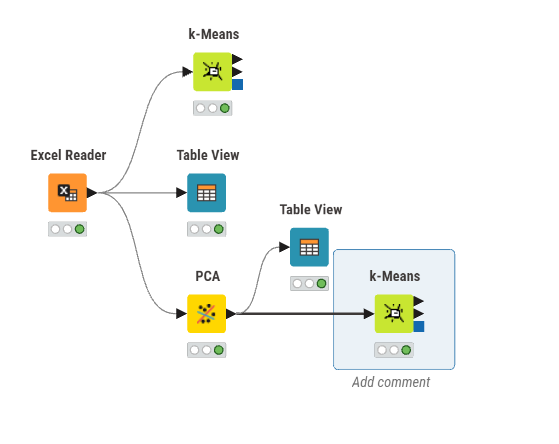

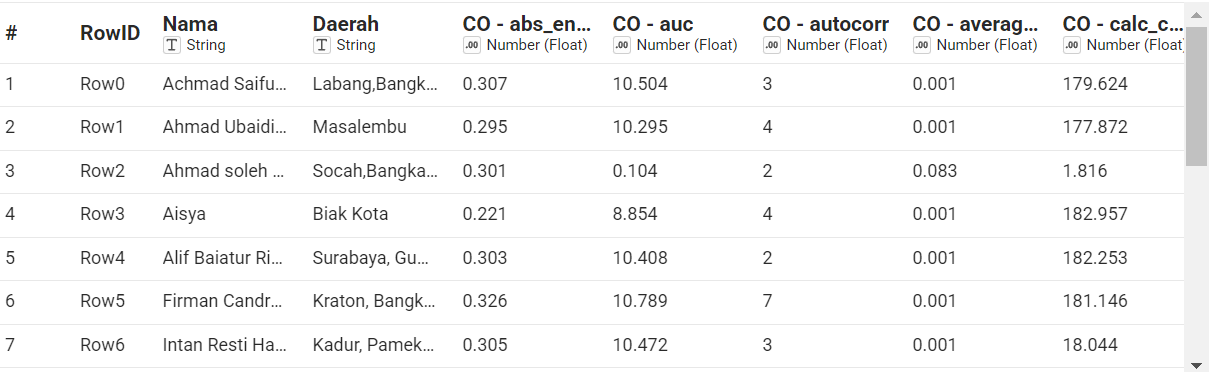

## 3. Skenario Eksperimen Pemodelan

Eksperimen klastering dibagi menjadi dua cabang (*branch*) pemrosesan paralel untuk tujuan komparasi:

### Skenario A: K-Means Langsung (Direct Clustering)
Pada skenario ini, seluruh fitur numerik asli hasil ekstraksi TSFEL langsung diumpankan ke algoritma K-Means.
*   **Jumlah Klaster ($k$):** Diinisialisasi sebanyak 3 kelompok ($k=3$). Angka ini dipilih karena dianggap paling representatif untuk merepresentasikan tingkat keparahan kualitas udara ke dalam tiga kategori logis (misalnya: Zona Hijau/Rendah, Zona Kuning/Sedang, dan Zona Merah/Tinggi).

### Skenario B: PCA dilanjutkan K-Means (Dimensionality Reduction)
Dengan jumlah fitur yang sangat masif akibat ekstraksi TSFEL, perhitungan jarak pada K-Means dapat menjadi tidak efisien dan rentan terhadap *noise*.
*   **Konfigurasi PCA:** Data numerik diekstraksi menggunakan PCA untuk mencari komponen utama yang paling banyak menyimpan varians data. Dimensi target direduksi menjadi **19 komponen utama** (menyesuaikan batas maksimal matriks dari observasi 19 mahasiswa).
*   **K-Means:** Hasil transformasi 19 komponen dimensi ortogonal dari PCA tersebut kemudian diumpankan ke algoritma K-Means dengan pengaturan $k=3$ untuk menguji apakah struktur kelompok berubah setelah dimensi diringkas.

## 4. Hasil Pengelompokan Data

### A. Hasil Klaster Skenario A (Tanpa PCA)
Berdasarkan eksekusi model K-Means tanpa reduksi dimensi, dataset terbagi menjadi tiga kelompok utama. Berikut adalah cuplikan hasil pemetaan dari *Table View*:

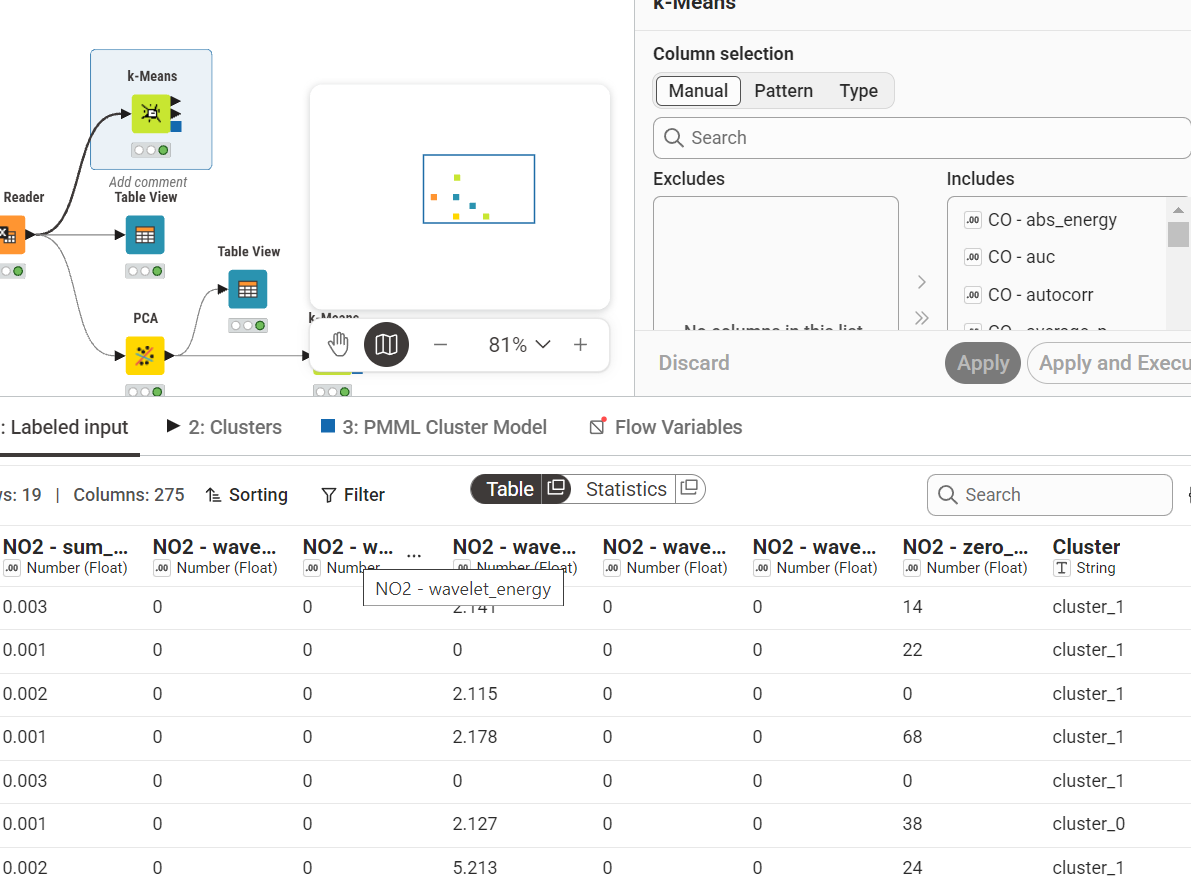

**Daftar Anggota Klaster:**
*   **Cluster 0:** *(Firman Candra Dwi Nugroho)* - Merepresentasikan daerah dengan karakteristik polusi tipe A.
*   **Cluster 1:** *(Achmad Saiful Fuadi,Ahmad Ubaidillah Mappattiro, Ahmad soleh majid, Aisya, Alif Baiatur Ridhwan El Habibie, Intan Resti Haslindawati, Irwan Dwi Mukhlisin, Kevin Koligombowo Mangaraja, Mohammad Andri Firmansyah, Mohammad Waqidi, Muhammad Ainul Fuady, Muhammad Ilham, Muhammad Sirul Amin, Raihan Aryanova Narendra, Shofiatul Mahmudah, Wildan Haydar Amru, fikri mutawakkil)* - Merepresentasikan daerah dengan karakteristik polusi tipe B.
*   **Cluster 2:** *(Muhammad Fathul Iman Wahid)* - Merepresentasikan daerah dengan karakteristik polusi tipe C.

### B. Hasil Klaster Skenario B (Dengan PCA)
Pada skenario kedua, pengelompokan didasarkan pada komponen utama (Principal Components). Berikut adalah hasil pemetaannya:

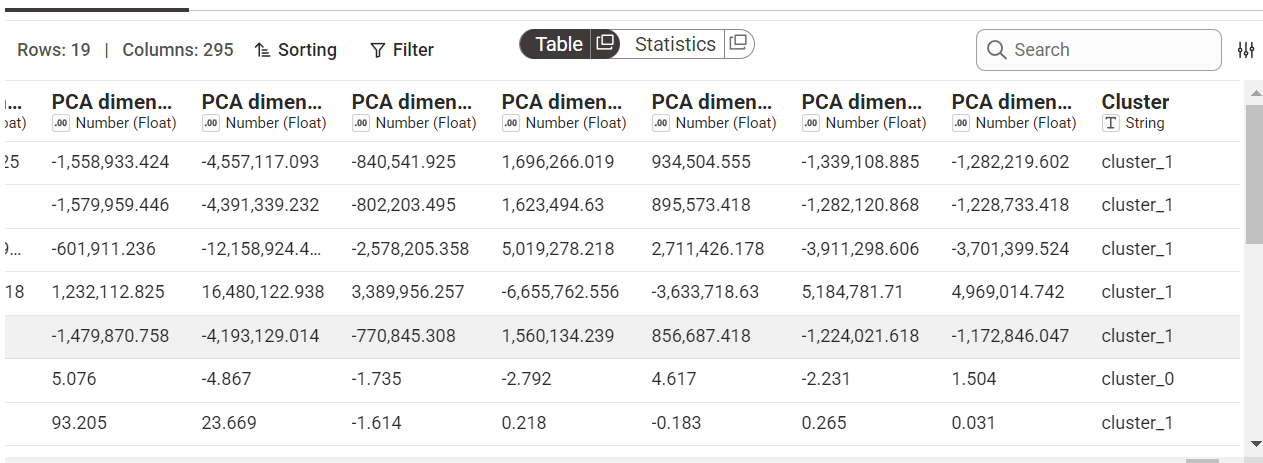

**Daftar Anggota Klaster:**
*   **Cluster 0:** *(Firman Candra Dwi Nugroho)* - Merepresentasikan daerah dengan karakteristik polusi tipe A.
*   **Cluster 1:** *(Achmad Saiful Fuadi,Ahmad Ubaidillah Mappattiro, Ahmad soleh majid, Aisya, Alif Baiatur Ridhwan El Habibie, Intan Resti Haslindawati, Irwan Dwi Mukhlisin, Kevin Koligombowo Mangaraja, Mohammad Andri Firmansyah, Mohammad Waqidi, Muhammad Ainul Fuady, Muhammad Ilham, Muhammad Sirul Amin, Raihan Aryanova Narendra, Shofiatul Mahmudah, Wildan Haydar Amru, fikri mutawakkil)* - Merepresentasikan daerah dengan karakteristik polusi tipe B.
*   **Cluster 2:** *(Muhammad Fathul Iman Wahid)* - Merepresentasikan daerah dengan karakteristik polusi tipe C.

## 5. Analisis dan Pembahasan
Berdasarkan pengamatan terhadap hasil *Table View*, pengelompokan yang dihasilkan oleh K-Means murni maupun K-Means berbasis PCA menghasilkan pemetaan anggota klaster yang identik. Hal ini mengindikasikan bahwa penggunaan 19 dimensi utama (PC) pada PCA berhasil mempertahankan 100% varians dan informasi krusial dari dataset aslinya. Karena jumlah sampel hanya 19 baris, reduksi menjadi 19 dimensi tidak menghilangkan struktur geometris data awal, sehingga jarak antar titik (*centroid*) tidak mengalami pergeseran yang berarti.

## 6. Kesimpulan
1. Implementasi algoritma K-Means berhasil memisahkan daerah observasi 19 mahasiswa ke dalam 3 klaster berbeda berdasarkan profil 68 fitur TSFEL dari polutan CO, NO2, SO2, dan CH4.
2. Penanganan nilai kosong (*missing value*) mutlak diperlukan karena keterbatasan metrik jarak *Euclidean* pada algoritma pembentukan klaster.
3. Penerapan PCA sebagai langkah pra-pemrosesan tambahan terbukti efektif dalam mereduksi dimensi data yang masif dari proses rekayasa fitur (*feature engineering*), mengoptimalkan representasi matematis sebelum diolah lebih lanjut oleh model K-Means.